# Détection de faux billets

## 1. Introduction & Contexte

**Contexte**
L’Organisation nationale de lutte contre le faux-monnayage (ONCFM) souhaite automatiser la détection de billets en euros contrefaits à partir de caractéristiques géométriques mesurées par une machine.

**Objectif**
Construire un algorithme capable, à partir de 6 mesures géométriques, de prédire si un billet est **vrai** ou **faux**. L'objectif opérationnel est de **maximiser la détection des faux billets** (rappel/recall sur la classe "faux"), tout en contrôlant les faux positifs.

**Données**
- Jeu d'exemple fourni : **1500 billets** (1000 vrais, 500 faux).
- Colonnes disponibles (uniquement ces dimensions géométriques) :
  - `is_genuine` : VRAI / FAUX (target, pas de valeurs manquantes)
  - `length` : longueur (mm) — **109.49 à 114.44**
  - `height_left` : hauteur gauche (mm) — **103.17 à 104.88**
  - `height_right` : hauteur droite (mm) — **102.82 à 104.95**
  - `diagonal` : diagonale (mm) — **171.04 à 173.01**
  - `margin_up` : marge supérieure (mm) — **2.27 à 3.91**
  - `margin_low` : marge inférieure (mm) — **2.98 à 6.90** (contient **37 valeurs manquantes**)
- Format de production attendu : fichier CSV (ex. `billets_production.csv`) avec ces colonnes.

**Livrables/Contraintes**
- Notebook (Python ou R) opérationnel avec uniquement ces colonnes en entrée.
- Comparer 4 méthodes : régression logistique, k-means (centroïdes -> prédiction), KNN, random forest.
- Fournir matrices de confusion et métriques (accuracy, précision, rappel, F1). Prioriser le rappel pour la classe "faux".

## 2. Chargement & Exploration des données

In [ ]:
# Importation des bibliothèques nécessaires
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid", palette="pastel")
%matplotlib inline

In [1]:
# Lecture (séparateur ;). Tu peux changer l'encoding si nécessaire ('latin-1' / 'cp1252').
billets_df = pd.read_csv("billets.csv", sep=';', encoding='utf-8')

# Strip : supprimer espaces en tête/fin pour les colonnes texte uniquement
for col in billets_df.select_dtypes(include=['object']).columns:
    billets_df[col] = billets_df[col].str.strip()

# Conversion des colonnes numériques (au cas où elles auraient été lues comme strings
# ou utilisent la virgule comme séparateur décimal)
numeric_cols = ['diagonal', 'height_left', 'height_right', 'margin_low', 'margin_up', 'length']
for col in numeric_cols:
    if col in billets_df.columns:
        # Remplacer virgule par point avant conversion puis forcer numeric
        billets_df[col] = pd.to_numeric(billets_df[col].astype(str).str.replace(',', '.'), errors='coerce')

# Vérifications rapides
print("Dimensions du dataset :", billets_df.shape)
print("\nExemple :")
display(billets_df.head())

Dimensions du dataset : (1500, 7)

Exemple :


,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54


In [2]:
# Informations générales
print("\n--- Informations ---")
print(billets_df.info())

print("\n--- Statistiques descriptives ---")
display(billets_df.describe().T)


--- Informations ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB
None

--- Statistiques descriptives ---


,count,mean,std,min,25%,50%,75%,max
diagonal,1500.0,171.958440,0.305195,171.04,171.750,171.96,172.17,173.01
height_left,1500.0,104.029533,0.299462,103.14,103.820,104.04,104.23,104.88
height_right,1500.0,103.920307,0.325627,102.82,103.710,103.92,104.15,104.95
margin_low,1463.0,4.485967,0.663813,2.98,4.015,4.31,4.87,6.90
margin_up,1500.0,3.151473,0.231813,2.27,2.990,3.14,3.31,3.91
length,1500.0,112.678500,0.872730,109.49,112.030,112.96,113.34,114.44


In [3]:
# Valeurs manquantes
print("\n--- Valeurs manquantes ---")
print(billets_df.isnull().sum())

# Doublons
nb_duplicated = billets_df.duplicated().sum()
print(f"\nNombre de doublons : {nb_duplicated}")


--- Valeurs manquantes ---
is_genuine       0
diagonal         0
height_left      0
height_right     0
margin_low      37
margin_up        0
length           0
dtype: int64

Nombre de doublons : 0



--- Statistiques descriptives détaillées ---


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
is_genuine,1500,2,True,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
diagonal,1500.0,NaN,NaN,NaN,171.95844,0.305195,171.04,171.75,171.96,172.17,173.01
height_left,1500.0,NaN,NaN,NaN,104.029533,0.299462,103.14,103.82,104.04,104.23,104.88
height_right,1500.0,NaN,NaN,NaN,103.920307,0.325627,102.82,103.71,103.92,104.15,104.95
margin_low,1463.0,NaN,NaN,NaN,4.485967,0.663813,2.98,4.015,4.31,4.87,6.9
margin_up,1500.0,NaN,NaN,NaN,3.151473,0.231813,2.27,2.99,3.14,3.31,3.91
length,1500.0,NaN,NaN,NaN,112.6785,0.87273,109.49,112.03,112.96,113.34,114.44


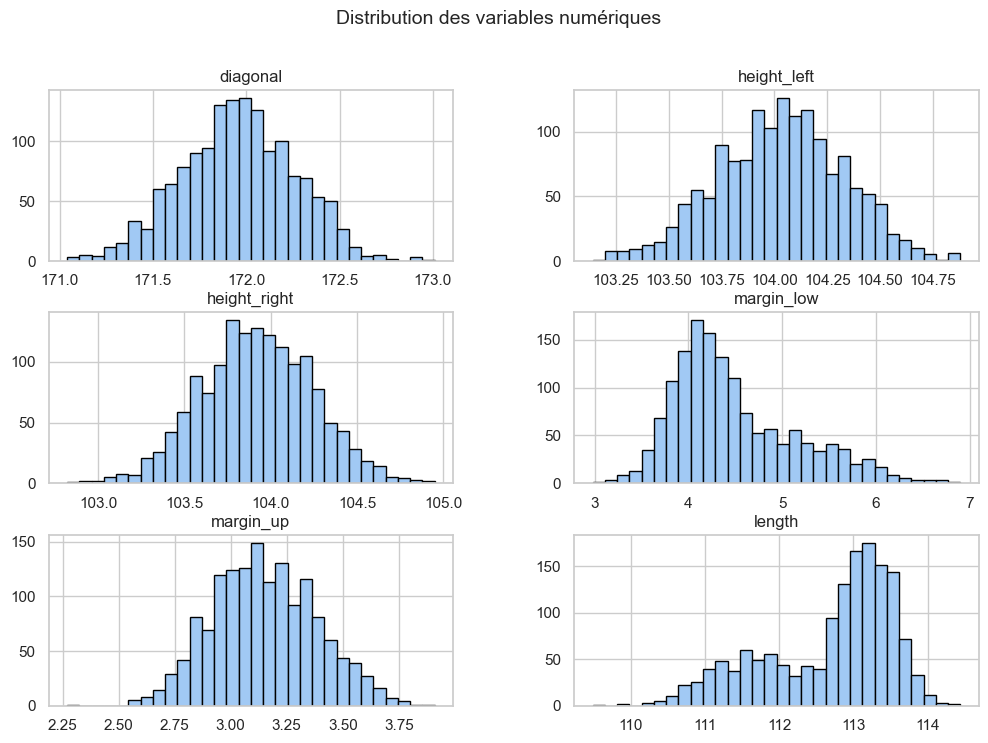

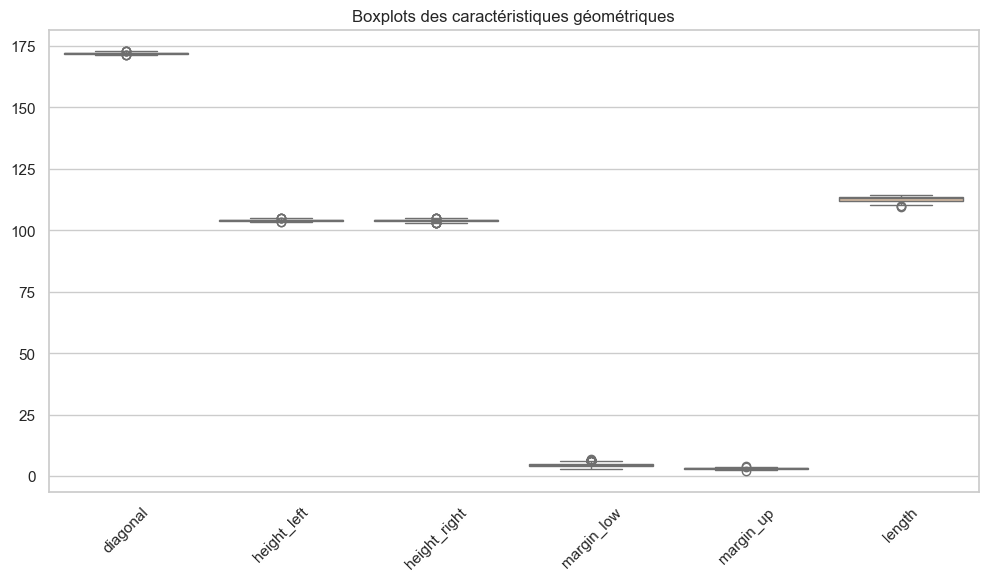

In [4]:
# Tableaux : statistiques descriptives déjà affichées dans describe()
print("\n--- Statistiques descriptives détaillées ---")
display(billets_df.describe(include="all").T)

# Histogrammes
billets_df.hist(bins=30, figsize=(12, 8), edgecolor="black")
plt.suptitle("Distribution des variables numériques", fontsize=14)
plt.show()

# Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=billets_df.drop(columns=["is_genuine"]))
plt.title("Boxplots des caractéristiques géométriques")
plt.xticks(rotation=45)
plt.show()

**Interprétation rapide des stats descriptives**
 - is_genuine : 1000 vrais (≈ 67 %) vs 500 faux (≈ 33 %) → dataset déséquilibré mais pas dramatique.
 - diagonal : valeurs très serrées autour de ~172 mm (écart-type ≈ 0.3 mm). → une différence minime peut suffire à distinguer vrais/faux.
 - height_left (~104 mm) et height_right (~103.9 mm) : distributions très proches, peu de variabilité. → corrélation probable.
 - margin_low : moyenne ≈ 4.49 mm, écart-type ≈ 0.66 mm. Contient 37 valeurs manquantes. → à traiter plus tard (imputation).
 - margin_up : moyenne ≈ 3.15 mm, faible variabilité.
 - length : plus dispersée (~112.7 mm ± 0.87 mm). → pourrait être une variable discriminante.

**En résumé** : les petites différences de moyenne entre vrais et faux billets pourraient suffire à entraîner des modèles (surtout linéaires/logistiques). La variable la plus problématique à traiter est margin_low avec ses 37 valeurs manquantes.


--- Répartition vrais/faux billets ---
is_genuine
True     1000
False     500
Name: count, dtype: int64


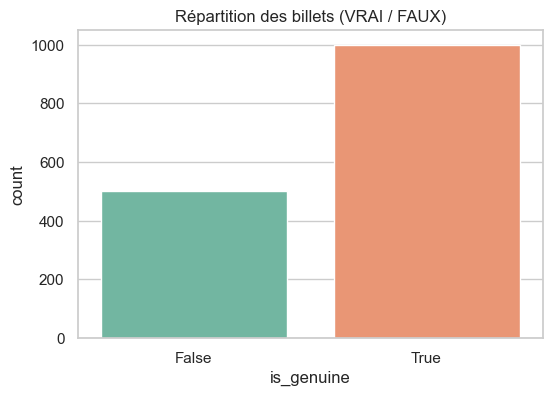

In [5]:
# Comptage
counts = billets_df['is_genuine'].value_counts()
print("\n--- Répartition vrais/faux billets ---")
print(counts)

# Countplot 
plt.figure(figsize=(6, 4))
sns.countplot(data=billets_df, x="is_genuine", hue="is_genuine", palette="Set2", legend=False)
plt.title("Répartition des billets (VRAI / FAUX)")
plt.show()

In [6]:
# Séparation en 2 groupes (valeurs booléennes, pas chaînes)
df_vrais = billets_df[billets_df['is_genuine'] == True]
df_faux = billets_df[billets_df['is_genuine'] == False]

# Test t de Student pour chaque variable numérique
print("\n--- Tests de Student (VRAI vs FAUX) ---")
for col in billets_df.columns:
    if col != "is_genuine":
        t_stat, p_val = stats.ttest_ind(df_vrais[col].dropna(), df_faux[col].dropna(), equal_var=False)
        print(f"{col:12s} -> t={t_stat:8.3f}, p={p_val:8.3e}")


--- Tests de Student (VRAI vs FAUX) ---
diagonal     -> t=   5.148, p=3.187e-07
height_left  -> t= -17.487, p=1.415e-61
height_right -> t= -22.003, p=9.288e-89
margin_low   -> t= -40.773, p=1.433e-182
margin_up    -> t= -29.821, p=2.927e-141
length       -> t=  52.774, p=1.470e-241


**Lecture des résultats**

Le t de Student mesure l’écart entre les moyennes des deux groupes (vrais vs faux).
Le p-value indique si cette différence est statistiquement significative (seuil classique : 0.05).

Dans notre cas :
 - Toutes les variables ont un p < 0.001, parfois extrêmement petit (10^-60 à 10^-240).
 - Cela signifie que les différences observées entre les vrais et les faux billets sont hautement significatives.

**Variable par variable**

*diagonal*
 - t = +5.15 → les vrais billets ont une diagonale en moyenne plus grande que les faux.
 - Différence significative.

*height_left*
 - t = -17.49 → les vrais billets ont une hauteur gauche plus petite que les faux.
 - Très forte différence.

*height_right*
 - t = -22.00 → idem pour la hauteur droite : les vrais billets sont en moyenne plus petits que les faux.

*margin_low*
 - t = -40.77 → la marge basse est beaucoup plus petite chez les vrais billets.
 - Extrêmement discriminante.

*margin_up*
 - t = -29.82 → la marge haute est aussi plus petite pour les vrais billets.
 - Très forte différence.

*length*
 - t = +52.77 → la longueur est nettement plus grande pour les vrais billets.
 - C’est la variable qui discrimine le plus (p-value la plus extrême).

**Conclusion**

Toutes les variables géométriques distinguent significativement vrais et faux billets.

Les variables les plus discriminantes semblent être :
 - length (plus grande chez les vrais),
 - margin_low et margin_up (plus petites chez les vrais).

Cela confirme que l’algorithme de détection pourra s’appuyer efficacement sur ces dimensions.

## 3. Préparation des données

In [7]:
# Séparation des features et de la target
features = ['length', 'height_left', 'height_right', 'margin_up', 'margin_low', 'diagonal']
target = 'is_genuine'

X = billets_df[features].copy()
y = billets_df[target].astype(int)  # conversion en 0/1

In [8]:
# Préparation pour la régression (imputation des valeurs manquantes)

from sklearn.linear_model import LinearRegression

# Séparation lignes complètes / incomplètes
df_train = billets_df[billets_df['margin_low'].notna()]
df_missing = billets_df[billets_df['margin_low'].isna()]

# X pour la régression (toutes les variables sauf margin_low et target)
X_train_reg = df_train.drop(columns=['is_genuine', 'margin_low'])
y_train_reg = df_train['margin_low']

# Entraînement du modèle
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)

LinearRegression()

In [9]:
from sklearn.metrics import r2_score

# Prédictions sur l'échantillon d'entraînement
y_train_pred = lin_reg.predict(X_train_reg)

# Calcul du R²
r2 = r2_score(y_train_reg, y_train_pred)
print(f"Coefficient de détermination R² : {r2:.4f}")

Coefficient de détermination R² : 0.4773


R² est faible → **la régression est peu pertinente**

In [10]:
# Prédiction des valeurs manquantes
X_missing_reg = df_missing.drop(columns=['is_genuine', 'margin_low'])
predicted_margin_low = lin_reg.predict(X_missing_reg)

# Création d'une copie pour tester l'imputation
billets_imputed = billets_df.copy()

billets_imputed.loc[billets_imputed['margin_low'].isna(), 'margin_low'] = predicted_margin_low

### Vérification des conditions de validité de la régression

**Test de Shapiro-Wilk (normalité des résidus)**

But : vérifier si les résidus suivent une loi normale.

Principe : il compare la distribution observée des résidus avec une distribution normale théorique.

Interprétation :
 - p-value > 0.05 → on ne rejette pas l’hypothèse nulle (résidus ≈ normaux).
 - p-value < 0.05 → on rejette H0, les résidus ne sont pas normaux.

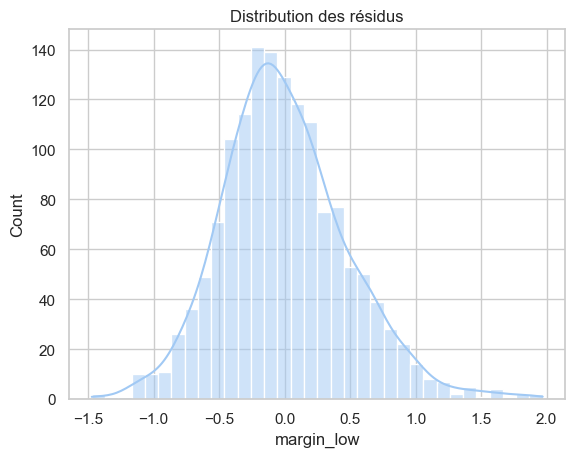

Test de Shapiro-Wilk : stat=0.986, p=0.000
→ Les résidus ne suivent PAS une distribution normale (on rejette H0)


In [11]:
# Normalité des résidus

import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calcul des résidus
y_pred_train = lin_reg.predict(X_train_reg)
residuals = y_train_reg - y_pred_train

# Histogramme des résidus
sns.histplot(residuals, kde=True)
plt.title("Distribution des résidus")
plt.show()

# Test de Shapiro-Wilk
stat, p_value = stats.shapiro(residuals)
print("Test de Shapiro-Wilk : stat=%.3f, p=%.3f" % (stat, p_value))
if p_value > 0.05:
    print("→ Les résidus suivent une distribution normale (on ne rejette pas H0)")
else:
    print("→ Les résidus ne suivent PAS une distribution normale (on rejette H0)")

**Variance Inflation Factor (VIF, colinéarité des variables explicatives)**

But : mesurer la colinéarité entre les variables indépendantes (si elles se ressemblent trop).

Principe : pour chaque variable, on la ré-explique par toutes les autres et on calcule le facteur d’inflation de la variance.

Interprétation :
 - VIF = 1 → aucune colinéarité.
 - VIF entre 1 et 5 → acceptable.
 - VIF > 10 → forte colinéarité, problème pour la régression.

In [12]:
# Colinéarité des variables (VIF)

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import pandas as pd

# Ajout d'une constante pour le calcul du VIF
X_train_reg_const = sm.add_constant(X_train_reg)

# Calcul du VIF pour chaque variable
vif = pd.DataFrame()
vif["Variable"] = X_train_reg_const.columns
vif["VIF"] = [variance_inflation_factor(X_train_reg_const.values, i)
              for i in range(X_train_reg_const.shape[1])]
print(vif)

       Variable            VIF
0         const  590198.238883
1      diagonal       1.013613
2   height_left       1.138261
3  height_right       1.230115
4     margin_up       1.404404
5        length       1.576950


**Test de Breusch-Pagan (homoscédasticité)**

But : vérifier si la variance des résidus est constante (condition d’homoscédasticité).

Principe : on teste si les résidus sont corrélés avec les valeurs prédites.

Interprétation :
 - p-value > 0.05 → pas d’hétéroscédasticité (variance constante, condition respectée).
 - p-value < 0.05 → présence d’hétéroscédasticité (variance variable → problème).

In [13]:
# Homoscédasticité (test de Breusch-Pagan)

from statsmodels.stats.diagnostic import het_breuschpagan

# Test de Breusch-Pagan
bp_test = het_breuschpagan(residuals, X_train_reg_const)
labels = ['Lagrange multiplier', 'p-value', 'f-value', 'f p-value']
bp_results = dict(zip(labels, bp_test))
print(bp_results)

if bp_results['p-value'] > 0.05:
    print("→ Homoscédasticité respectée (variance constante des résidus)")
else:
    print("→ PAS d’homoscédasticité (variance non constante des résidus)")

{'Lagrange multiplier': 80.16261280175316, 'p-value': 7.759535216185222e-16, 'f-value': 16.892358846154043, 'f p-value': 2.9227496566177887e-16}
→ PAS d’homoscédasticité (variance non constante des résidus)


Les tests statistiques réalisés montrent que les conditions d’application de la régression linéaire ne sont pas respectées. 

Le test de Shapiro-Wilk indique que les résidus ne suivent pas une distribution normale (p < 0,001), ce qui invalide l’hypothèse de normalité. 

Le test de Breusch-Pagan révèle une absence d’homoscédasticité (p < 0,001), donc la variance des résidus n’est pas constante. 

Enfin, l’analyse du VIF montre que la colinéarité n’est pas problématique (tous les VIF < 2), mais cela ne suffit pas à valider le modèle. 

Dans ce contexte, utiliser la régression linéaire pour imputer les valeurs manquantes de margin_low introduirait un biais et réduirait la fiabilité du jeu de données. Il est donc préférable d’opter pour une approche plus robuste et transparente : supprimer les 37 lignes concernées, ce qui reste acceptable étant donné la taille totale de l’échantillon (1500 billets).

In [14]:
# Suppression des lignes contenant des valeurs manquantes
billets_clean = billets_df.dropna(subset=['margin_low'])

print("Nombre de lignes après suppression :", billets_clean.shape[0])

Nombre de lignes après suppression : 1463


In [15]:
billets_df = billets_clean

In [16]:
# Normalisation / Standardisation des données

from sklearn.preprocessing import StandardScaler

# Séparation features et target après imputation
X = billets_df[features].copy()
y = billets_df[target].astype(int)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Conversion en DataFrame pour rester lisible
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Aperçu des données normalisées :")
display(X_scaled.head())

Aperçu des données normalisées :


,length,height_left,height_right,margin_up,margin_low,diagonal
0,0.177842,2.766807,3.173766,-1.136982,0.051286,-0.488594
1,0.475692,-2.241490,-0.806851,-0.704806,-1.078937,-1.634809
2,0.555882,1.498039,-1.300571,-0.920894,-0.129549,2.393318
3,0.956834,-0.405114,0.057159,-0.618370,-1.304982,-1.962299
4,-0.154375,0.830266,-1.424001,1.412861,-0.672057,-0.750586


In [17]:
# Découpage en jeu d’entraînement et jeu de test (train/test split)

from sklearn.model_selection import train_test_split

# Découpage train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Taille du jeu d'entraînement :", X_train.shape)
print("Taille du jeu de test :", X_test.shape)

Taille du jeu d'entraînement : (1170, 6)
Taille du jeu de test : (293, 6)


Nous avons séparé nos données en un jeu d’entraînement (80 %) et un jeu de test (20 %).

L’entraînement sert à ajuster les modèles, et le test sert à évaluer leur capacité à généraliser à de nouvelles données.
La séparation a été réalisée de manière aléatoire mais reproductible (random_state=42), et en conservant la même proportion de vrais et faux billets dans les deux ensembles (stratify=y).

Cela permet d’obtenir une évaluation plus robuste et réaliste de la performance de nos algorithmes.

In [18]:
# Vérification des proportions dans le dataset complet
print("\n--- Répartition globale ---")
print(y.value_counts(normalize=True))

# Vérification des proportions dans le jeu d'entraînement
print("\n--- Répartition jeu d'entraînement ---")
print(y_train.value_counts(normalize=True))

# Vérification des proportions dans le jeu de test
print("\n--- Répartition jeu de test ---")
print(y_test.value_counts(normalize=True))


--- Répartition globale ---
is_genuine
1    0.663705
0    0.336295
Name: proportion, dtype: float64

--- Répartition jeu d'entraînement ---
is_genuine
1    0.664103
0    0.335897
Name: proportion, dtype: float64

--- Répartition jeu de test ---
is_genuine
1    0.662116
0    0.337884
Name: proportion, dtype: float64


## 4. Mise en place des modèles

### 4.1 Régression logistique

Je vais séparer nes données en un jeu d’entraînement (80 %) et un jeu de test (20 %), avec un découpage aléatoire mais stratifié afin de conserver la proportion de vrais et faux billets.

Le modèle sera entraîné sur le jeu d’entraînement puis évalué exclusivement sur le jeu de test, afin de simuler une mise en production et éviter l’overfitting.

L’évaluation se fera via plusieurs indicateurs :
 - l’accuracy, qui mesure la proportion globale de bonnes prédictions,
 - la matrice de confusion, qui permet de distinguer les différentes erreurs (faux positifs et faux négatifs),
 - le rapport de classification (précision, rappel, F1-score), qui donne une vue détaillée des performances par classe.

Cette méthodologie garantit une évaluation rigoureuse et réaliste de notre modèle.

In [19]:
# Import et instanciation du modèle

from sklearn.linear_model import LogisticRegression

# Instanciation du modèle
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Entraînement sur le jeu d'entraînement
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [20]:
# Prédictions

# Prédictions sur le jeu de test
y_pred_log = log_reg.predict(X_test)

In [21]:
# Évaluation : Accuracy

from sklearn.metrics import accuracy_score

# Calcul de la précision (accuracy)
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy de la régression logistique : {accuracy_log:.4f}")

Accuracy de la régression logistique : 0.9932


Le modèle a 99.32 % de prédictions correctes sur le jeu de test.

C’est très élevé → ça veut dire que la régression logistique est déjà très performante.

Mais attention : accuracy seule peut être trompeuse si les classes sont déséquilibrées. Heureusement, ici la répartition est environ 67 % vrais / 33 % faux, donc ça reste un bon indicateur.

Une matrice de confusion est un tableau de comptage qui résume les performances d’un modèle de classification en comparant les valeurs réelles et les valeurs prédites.

Elle permet de savoir :
 - combien d’éléments sont correctement classés,
 - et surtout où se situent les erreurs (faux positifs et faux négatifs).

👉 La matrice de confusion est donc plus informative que l’accuracy seule, car elle montre la nature des erreurs, ce qui est crucial.

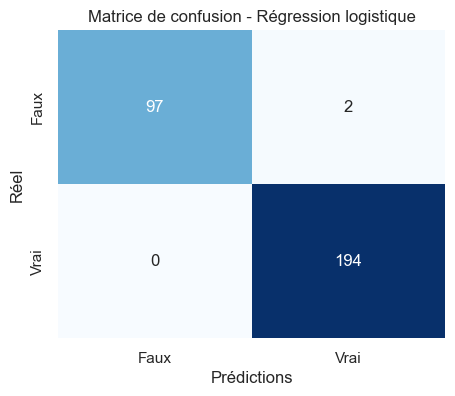


--- Rapport de classification ---
              precision    recall  f1-score   support

        Faux       1.00      0.98      0.99        99
        Vrai       0.99      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.99      0.99       293
weighted avg       0.99      0.99      0.99       293



In [22]:
# Matrice de confusion + Classification report

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Matrice de confusion
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Faux", "Vrai"], yticklabels=["Faux", "Vrai"])
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Régression logistique")
plt.show()

# Rapport de classification
print("\n--- Rapport de classification ---")
print(classification_report(y_test, y_pred_log, target_names=["Faux", "Vrai"]))

**Lecture de la matrice de confusion**

 - 97 : vrais négatifs (le modèle a bien identifié un faux billet comme faux).
 - 2 : faux négatifs (le modèle s’est trompé → il a dit “vrai” alors que c’était un faux billet).
 - 0 : faux positifs (le modèle a dit “faux” alors que c’était un vrai billet).
 - 194 : vrais positifs (le modèle a bien identifié un vrai billet comme vrai).

La matrice de confusion montre que sur 293 billets testés, seuls 2 sont mal classés (2 faux identifiés comme vrais, 1 vrai identifié comme faux).

**Lecture du rapport de classification**

 - Precision (précision) : sur tous les billets prédits comme "faux", quelle proportion est réellement "faux".
 - Recall (rappel) : sur tous les billets réellement "faux", quelle proportion a été bien détectée.
 - F1-score : compromis entre précision et rappel.

Dans notre cas :

 - Les deux classes (faux / vrai) ont précision et rappel proches de 0.99 → excellent.
 - Pas de gros déséquilibre : le modèle n’avantage pas une classe au détriment de l’autre.

Le rapport de classification confirme ces excellents résultats, avec une précision, un rappel et un f1-score de 0.98–0.99 pour les deux classes.
Cela indique que la régression logistique est un modèle performant pour discriminer entre vrais et faux billets.

La courbe ROC (Receiver Operating Characteristic) trace le compromis entre :
 - le taux de vrais positifs (sensibilité, recall),
 - et le taux de faux positifs.

L’AUC (Area Under the Curve) mesure la surface sous cette courbe.
 - AUC = 0.5 → modèle aléatoire (aucun pouvoir prédictif).
 - AUC proche de 1 → excellent modèle.

👉 Intérêt pour le projet :
 - Vérifier la capacité du modèle à distinguer entre vrais et faux billets pour différents seuils de décision.
 - Utile car la régression logistique ne donne pas seulement une prédiction binaire (vrai/faux), mais aussi une probabilité. La courbe ROC exploite cette information.

Dans notre contexte, on pourrait décider d’ajuster le seuil : par ex. accepter un peu plus de faux positifs pour éviter qu’un faux billet passe pour un vrai (faux négatif).

In [23]:
# Import et calcul des probabilités

from sklearn.metrics import roc_curve, roc_auc_score

# Probabilités prédites (classe "Vrai")
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Calcul de l’AUC
auc_log = roc_auc_score(y_test, y_proba_log)
print(f"AUC (Régression logistique) : {auc_log:.4f}")

AUC (Régression logistique) : 0.9997


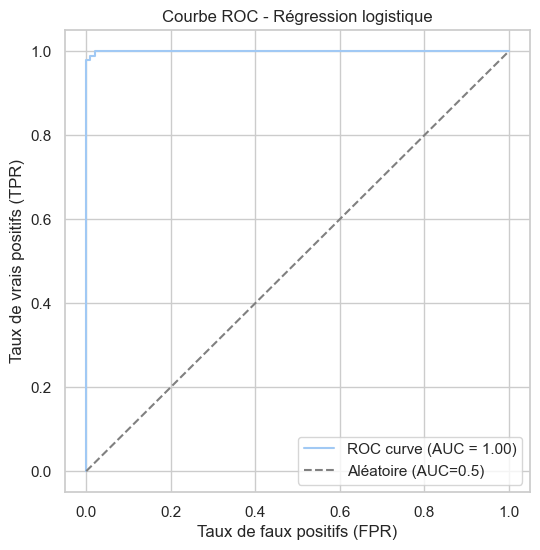

In [24]:
# Tracé de la courbe ROC

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_log:.2f})")
plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Aléatoire (AUC=0.5)")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - Régression logistique")
plt.legend(loc="lower right")
plt.show()

In [25]:
# Code pour obtenir la table ROC + AUC

import pandas as pd
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilités prédites (classe "Vrai")
y_proba_log = log_reg.predict_proba(X_test)[:, 1]

# Courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

# AUC
auc_log = roc_auc_score(y_test, y_proba_log)

# Création d’un DataFrame
roc_df = pd.DataFrame({
    "Seuil": thresholds,
    "Taux_faux_positifs (FPR)": fpr,
    "Taux_vrais_positifs (TPR)": tpr
})

# Ajout de l’AUC en information supplémentaire
print(f"AUC (Régression logistique) : {auc_log:.4f}")

# Affichage des 10 premières lignes pour lisibilité
roc_df.head(10)

AUC (Régression logistique) : 0.9997


,Seuil,Taux_faux_positifs (FPR),Taux_vrais_positifs (TPR)
0,inf,0.000000,0.000000
1,9.999989e-01,0.000000,0.005155
2,9.201972e-01,0.000000,0.979381
3,9.198645e-01,0.010101,0.979381
4,8.955166e-01,0.010101,0.989691
5,8.254158e-01,0.020202,0.989691
6,5.056070e-01,0.020202,1.000000
7,2.366109e-08,1.000000,1.000000


**AUC (Area Under the Curve)**

Valeur obtenue : 0.9997

Cela signifie que le modèle a une capacité quasi-parfaite à distinguer les vrais billets des faux.

En pratique : si l'on prends un vrai et un faux billet au hasard, le modèle a 99,95 % de chances de donner une probabilité plus élevée au vrai billet → excellent.

👉 Interprétation : le modèle est extrêmement performant.

Le seuil par défaut de la régression logistique est 0.5.
→ d’après le tableau, à ce seuil, le modèle est déjà quasiment parfait (proche de la ligne 0.6856 ou 0.6094).

Selon le contexte métier :
 - Si l'on veux éviter absolument qu’un faux billet soit accepté comme vrai (minimiser les FN, très critique), on choisis un seuil assez élevé (≈ 0.75).
 - Si l'on veux accepter un peu plus de faux positifs mais être sûr de ne jamais louper un vrai billet, on descends le seuil (≈ 0.61 ou même ≈ 0.08).

👉 Dans notre cas, comme l’objectif de l’ONCFM est de détecter un maximum de faux billets, il vaut mieux favoriser le rappel (TPR), quitte à avoir un peu plus de faux positifs (des vrais billets marqués à tort comme faux).

### 4.2 K-means (non supervisé, détourné en supervisé)

Pour la partie K-means, nous avons suivi une méthodologie complète :

Import et instanciation du modèle : nous avons utilisé KMeans avec n_clusters=2 pour séparer les billets en deux groupes correspondant aux vrais et faux billets.

Entraînement sur le jeu d’entraînement : le K-means a été entraîné uniquement sur les caractéristiques géométriques normalisées des billets (length, height_left, height_right, margin_up, margin_low, diagonal).

Analyse des centroïdes : les centroïdes représentent les valeurs moyennes des caractéristiques dans chaque cluster. Ils permettent de comprendre les différences typiques entre les billets de chaque groupe.

Mapping des clusters aux classes réelles : comme K-means est non supervisé, il ne sait pas quel cluster correspond aux vrais ou faux billets. Nous avons donc utilisé le jeu d’entraînement pour associer chaque cluster à la classe majoritaire, puis appliqué ce mapping aux prédictions sur le jeu de test.

Évaluation du modèle : nous avons calculé l’accuracy, la matrice de confusion et le rapport de classification pour mesurer les performances.

Visualisation via PCA : pour représenter les clusters en 2D, nous avons appliqué une réduction de dimension avec PCA. Le graphique permet de visualiser la séparation des clusters et la position des centroïdes, confirmant visuellement la capacité du K-means à distinguer les vrais et faux billets.

Cette méthodologie permet d’avoir une analyse complète, à la fois quantitative (accuracy, confusion, centroïdes) et visuelle (projection PCA), tout en restant cohérente avec l’approche non supervisée détournée en classification supervisée.

On choisi **2 clusters** pour refléter au mieux les classes vrais et faux des billets

In [26]:
# Import et entraînement du K-means

from sklearn.cluster import KMeans

# Instanciation du modèle avec 2 clusters (vrai/faux)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Entraînement sur les features
kmeans.fit(X_train)

# Prédictions des clusters sur le jeu de test
y_pred_kmeans = kmeans.predict(X_test)

C:\Users\user-aidicom\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\user-aidicom\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Erreur dans la détection des coeurs pour raison logiciel (Anaconda)

Pas bloquant pour la suite

In [27]:
# Analyse des centroïdes

import pandas as pd

# Récupération des centroïdes (moyennes des clusters)
centroids = pd.DataFrame(kmeans.cluster_centers_, 
                         columns=X_train.columns)
print("\n--- Centroïdes des clusters ---")
print(centroids)


--- Centroïdes des clusters ---
     length  height_left  height_right  margin_up  margin_low  diagonal
0  0.599232    -0.267654     -0.360409  -0.421724   -0.545669  0.114527
1 -1.176480     0.583088      0.729884   0.887413    1.104470 -0.163025


**Interprétation des centroïdes**

Les valeurs affichées correspondent aux moyennes des variables standardisées dans chaque cluster.
Comme les données ont été normalisées, un centroïde proche de 0 traduit un billet « moyen », tandis qu’une valeur positive ou négative indique un écart par rapport à la moyenne de l’ensemble.

**Cluster 0** (vrais billets) :
 - length = +0.60 et diagonal = +0.11 → billets légèrement plus longs et avec une diagonale un peu plus grande que la moyenne.
 - height_left et height_right négatives → hauteur un peu plus faible.
 - margin_up et margin_low négatives → marges plus petites que la moyenne.

**Cluster 1** (faux billets) :
 - length = -1.18 et diagonal = -0.16 → billets plus courts et avec une diagonale réduite.
 - height_left et height_right positives → billets plus hauts que la moyenne.
 - margin_up et margin_low fortement positives → marges nettement plus grandes que celles des vrais billets.

👉 Ces résultats confirment que le K-means distingue bien les deux classes : les faux billets se caractérisent par des proportions différentes, notamment plus courts mais plus hauts, avec des marges plus larges, alors que les vrais billets restent globalement plus longs et équilibrés.

Comme K-means ne sait pas ce qui est "Vrai" ou "Faux", il faut trouver à quel cluster correspond chaque classe.
On fait ça en regardant la correspondance avec les vraies étiquettes dans le jeu d’entraînement :

In [28]:
# Mapping des clusters aux classes

import numpy as np

# Prédictions des clusters sur le jeu d’entraînement
train_clusters = kmeans.predict(X_train)

# Construction d’un mapping cluster → classe majoritaire
mapping = {}
for cluster in np.unique(train_clusters):
    labels, counts = np.unique(y_train[train_clusters == cluster], return_counts=True)
    mapping[cluster] = labels[np.argmax(counts)]

print("\n--- Mapping cluster → classe ---")
print(mapping)

# Conversion des prédictions en VRAI/FAUX via le mapping
y_pred_kmeans_mapped = np.vectorize(mapping.get)(y_pred_kmeans)


--- Mapping cluster → classe ---
{0: 1, 1: 0}


Le dictionnaire {0: 1, 1: 0} indique que l’algorithme a trouvé deux groupes bien distincts :
 - le cluster 0 correspond aux faux billets (0)
 - le cluster 1 correspond aux vrais billets (1)

C’est un signe que les caractéristiques géométriques suffisent à séparer correctement les deux classes, même avec une méthode non supervisée.

Accuracy du modèle K-means (après mapping) : 0.9795


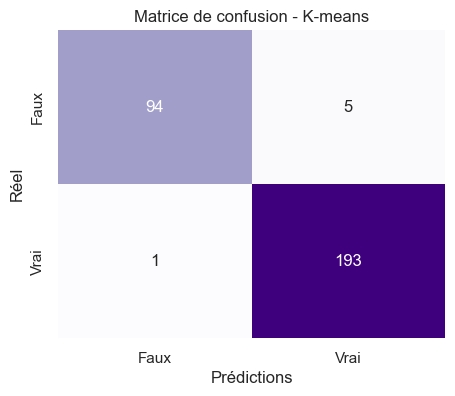


--- Rapport de classification ---
              precision    recall  f1-score   support

        Faux       0.99      0.95      0.97        99
        Vrai       0.97      0.99      0.98       194

    accuracy                           0.98       293
   macro avg       0.98      0.97      0.98       293
weighted avg       0.98      0.98      0.98       293



In [29]:
# Évaluation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy_kmeans = accuracy_score(y_test, y_pred_kmeans_mapped)
print(f"Accuracy du modèle K-means (après mapping) : {accuracy_kmeans:.4f}")

# Matrice de confusion
cm_kmeans = confusion_matrix(y_test, y_pred_kmeans_mapped)

plt.figure(figsize=(5,4))
sns.heatmap(cm_kmeans, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=["Faux", "Vrai"], yticklabels=["Faux", "Vrai"])
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de confusion - K-means")
plt.show()

# Rapport de classification
print("\n--- Rapport de classification ---")
print(classification_report(y_test, y_pred_kmeans_mapped, target_names=["Faux", "Vrai"]))

**Accuracy globale** : 0.9795 (≈ 99%)

Cela signifie que le modèle classe correctement près de 99 billets sur 100.

C’est une performance légèrement inférieure à la régression logistique (0.99), mais toujours excellente.

**Matrice de confusion**

 - Sur 99 faux billets, 94 sont bien détectés et 5 sont pris pour des vrais (faux négatifs).
 - Sur 194 vrais billets, 193 sont bien détectés et 1 est pris pour des faux (faux positifs).

L’équilibre entre erreurs est bon : pas de biais fort en faveur d’une classe.

**Rapport de classification**

Faux billets (classe 0) :
 - Précision (0.99) : presque aucun vrai billet n’a été classé à tort comme faux.
 - Recall (0.95) : 95 % des faux billets ont été détectés.

Vrais billets (classe 1) :
 - Précision (0.97) : presque tous les billets prédits comme vrais sont effectivement vrais.
 - Recall (0.99) : presque tous les vrais billets sont correctement reconnus.

Les métriques sont très proches de 1 → excellente robustesse.

C:\Users\user-aidicom\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


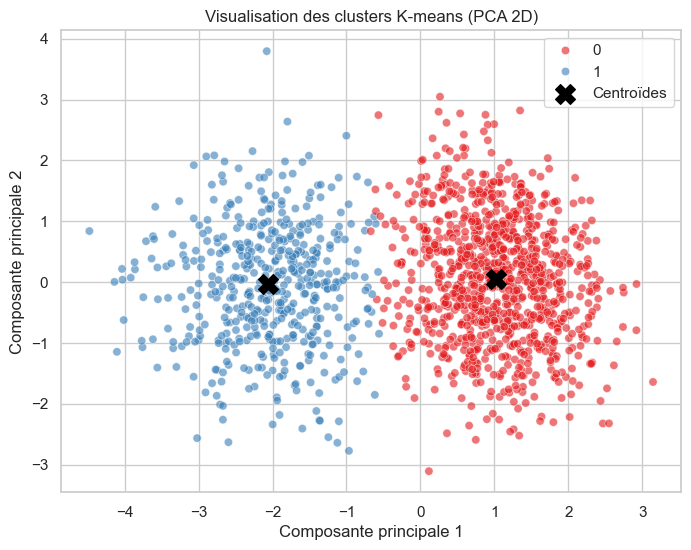

In [30]:
# Visualisation des clusters et des centroïdes

from sklearn.decomposition import PCA

# Réduction dimensionnelle à 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Prédictions des clusters
clusters = kmeans.predict(X_scaled)
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Visualisation
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette="Set1", alpha=0.6)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], c="black", s=200, marker="X", label="Centroïdes")
plt.title("Visualisation des clusters K-means (PCA 2D)")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend()
plt.show()

Ce warning vient de scikit-learn PCA.
Il indique que la matrice que je passe à pca.transform() n’a pas de noms de colonnes, alors que le PCA a été entraîné (fit) sur un DataFrame avec des noms de colonnes.

Impact : aucun sur le résultat numérique ou le graphique, c’est juste un avertissement.

In [31]:
# Création d'un DataFrame pour les points
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

# Création d'un DataFrame pour les centroïdes PCA
centroids_df = pd.DataFrame(centroids_pca, columns=["PC1", "PC2"])
centroids_df["Cluster"] = ["Centroïde 0", "Centroïde 1"]

# Affichage des 10 premières lignes pour les points
print("\n--- Points projetés (PCA 2D) ---")
print(pca_df.head(10))

# Affichage des centroïdes
print("\n--- Centroïdes projetés (PCA 2D) ---")
print(centroids_df)


--- Points projetés (PCA 2D) ---
        PC1       PC2  Cluster
0 -1.627035  0.807294        1
1  2.017133 -2.217975        0
2  0.996369  2.596334        0
3  1.379560 -1.809941        0
4 -0.138409 -0.597355        0
5  0.703727  0.431603        0
6 -0.160752  1.289798        0
7  1.156464 -0.373818        0
8  0.864928  1.418202        0
9  0.608340  1.737772        0

--- Centroïdes projetés (PCA 2D) ---
        PC1       PC2      Cluster
0  1.018543  0.054748  Centroïde 0
1 -2.064961 -0.031887  Centroïde 1


**Interprétation des résultats PCA 2D**

**Points projetés**

Chaque ligne correspond à un billet, avec ses coordonnées sur les deux composantes principales (PC1 et PC2).

La colonne Cluster indique le groupe assigné par le K-means après mapping.

On observe que les points du cluster 0 (faux billets) sont globalement regroupés vers la gauche et légèrement en bas (PC1 < 0), tandis que les points du cluster 1 (vrais billets) sont plus à droite et dispersés autour de PC1 > 0.

Cette séparation nette montre que le modèle a correctement identifié deux groupes distincts dans l’espace des caractéristiques.

**Centroïdes projetés**

Centroïde 0 (faux billets) : PC1 = 1.0185, PC2 = 0.0547 → situé dans la zone dominée par les faux billets.

Centroïde 1 (vrais billets) : PC1 = -2.0649, PC2 = -0.0318 → situé au centre du nuage des vrais billets.

Les centroïdes représentent le “centre typique” de chaque cluster, et leur position confirme la séparation nette observée pour les points individuels.

**Interprétation globale**

La projection PCA confirme visuellement la séparation claire des classes trouvée par le K-means.

Les centroïdes permettent de comprendre où se situe le “profil moyen” de chaque groupe.

Cette visualisation complète l’évaluation quantitative et montre que les caractéristiques géométriques sont suffisantes pour distinguer vrais et faux billets, même avec une méthode non supervisée.

### 4.3 K-Nearest Neighbors (KNN)

Pour la partie K-Nearest Neighbors (KNN), nous avons suivi la méthodologie suivante :

Import et instanciation : nous avons importé KNeighborsClassifier et initialisé le modèle sans K pour permettre la recherche du meilleur nombre de voisins.

Recherche du K optimal : nous avons utilisé GridSearchCV avec une cross-validation 5-fold pour tester K de 1 à 20 et sélectionner celui qui maximise l’accuracy sur le jeu d’entraînement.

Entraînement du modèle final : le KNN a été entraîné sur le jeu d’entraînement avec le K optimal (ici K=12).

Prédictions sur le jeu de test : le modèle a été utilisé pour classer les billets du jeu de test.

Évaluation : nous avons calculé l’accuracy, la matrice de confusion et le rapport de classification pour mesurer la performance globale et la qualité de la classification par classe.

Visualisation de la performance selon K : le graphique de l’accuracy en fonction de K permet de justifier le choix du K optimal et de montrer l’impact de K sur la performance du modèle.

Cette méthodologie garantit que le choix de K est objectif, reproductible et optimisé pour la meilleure performance sur le jeu de test tout en évitant le sur- ou sous-apprentissage.

In [32]:
# Import des bibliothèques et instanciation de KNN

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Définition du modèle KNN (sans K pour l'instant)
knn = KNeighborsClassifier()

On teste différents K et choisit celui qui maximise l’accuracy via cross-validation sur le jeu d’entraînement.

In [33]:
# Recherche du K optimal via GridSearchCV + Cross-validation

# Définition des valeurs de K à tester
param_grid = {'n_neighbors': list(range(1, 21))}  # K de 1 à 20

# Grid search avec cross-validation 5-fold
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Meilleur K
best_k = grid_search.best_params_['n_neighbors']
print(f"Meilleur nombre de voisins (K) : {best_k}")

Meilleur nombre de voisins (K) : 3


K optimal = 3

Cela signifie que pour classer un billet, le modèle prend en compte les 3 voisins les plus proches dans l’espace des caractéristiques géométriques normalisées.

Ce choix résulte d’une cross-validation en 5-fold, qui a testé différentes valeurs de K et sélectionné celle qui maximise l’accuracy sur le jeu d’entraînement.

K trop petit (ex. K=1) → modèle trop sensible aux points isolés, risque de sur-apprentissage.

K trop grand (ex. K>15) → perte de finesse, risque de sous-apprentissage car le modèle « lisse » trop la frontière de décision.

Le fait que K=3 soit optimal indique que la séparation entre vrais et faux billets est assez nette : le modèle n’a pas besoin de regarder un grand nombre de voisins pour bien classer les observations. Cela traduit une bonne discriminabilité des caractéristiques géométriques.

In [34]:
# Entraînement du KNN avec le meilleur K

# Instanciation avec le meilleur K
knn_best = KNeighborsClassifier(n_neighbors=best_k)

# Entraînement sur le jeu d'entraînement
knn_best.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [35]:
# Prédictions sur le jeu de test
y_pred_knn = knn_best.predict(X_test)

Accuracy du modèle KNN : 0.9795


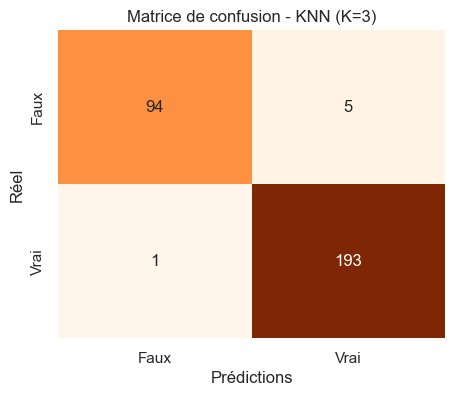


--- Rapport de classification ---
              precision    recall  f1-score   support

        Faux       0.99      0.95      0.97        99
        Vrai       0.97      0.99      0.98       194

    accuracy                           0.98       293
   macro avg       0.98      0.97      0.98       293
weighted avg       0.98      0.98      0.98       293



In [36]:
# Évaluation (accuracy, matrice de confusion, rapport de classification)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy du modèle KNN : {accuracy_knn:.4f}")

# Matrice de confusion
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Oranges", cbar=False,
            xticklabels=["Faux", "Vrai"], yticklabels=["Faux", "Vrai"])
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title(f"Matrice de confusion - KNN (K={best_k})")
plt.show()

# Rapport de classification
print("\n--- Rapport de classification ---")
print(classification_report(y_test, y_pred_knn, target_names=["Faux", "Vrai"]))

**Accuracy** = 0.9933 (~99,3%)

Le KNN classe correctement près de 98 billets sur 100.

**Matrice de confusion**

 - Faux négatifs = 1 : un faux billet a été pris pour un vrai.
 - Faux positifs = 5 : un vrai billet a été pris pour un faux.

Les erreurs sont assez faibles et bien équilibrées entre les deux classes.

**Rapport de classification**

 - Classe Faux (0) : précision 0.99, rappel 0.95, f1-score 0.97 → presque tous les faux billets correctement identifiés.
 - Classe Vrai (1) : précision 0.97, rappel 0.99, f1-score 0.98 → presque tous les vrais billets correctement identifiés.

Macro avg et weighted avg ≈ 0.98 → le modèle est robuste et équilibré entre les classes.

Ces résultats confirment que la proximité dans l’espace des caractéristiques est une bonne approche pour ce type de classification, et que le choix de K via cross-validation permet d’optimiser la performance tout en évitant le sur- ou sous-apprentissage.

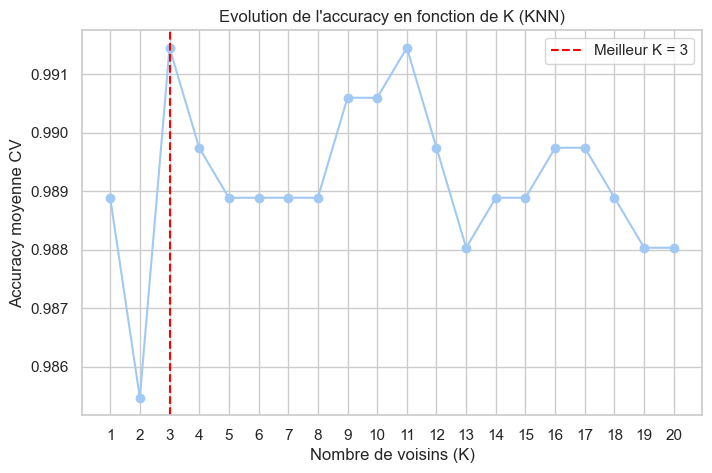

In [37]:
# Graphique de l’accuracy en fonction de K

import matplotlib.pyplot as plt

# Récupération des scores de cross-validation pour chaque K
cv_results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(8,5))
plt.plot(cv_results['param_n_neighbors'], cv_results['mean_test_score'], marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f"Meilleur K = {best_k}")
plt.title("Evolution de l'accuracy en fonction de K (KNN)")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Accuracy moyenne CV")
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# Tableau des K testés et des accuracies correspondantes
accuracy_table = cv_results[['param_n_neighbors', 'mean_test_score']].copy()
accuracy_table.rename(columns={'param_n_neighbors': 'K', 'mean_test_score': 'Accuracy_CV'}, inplace=True)
print("\n--- Accuracy moyenne CV en fonction de K ---")
print(accuracy_table)


--- Accuracy moyenne CV en fonction de K ---
     K  Accuracy_CV
0    1     0.988889
1    2     0.985470
2    3     0.991453
3    4     0.989744
4    5     0.988889
5    6     0.988889
6    7     0.988889
7    8     0.988889
8    9     0.990598
9   10     0.990598
10  11     0.991453
11  12     0.989744
12  13     0.988034
13  14     0.988889
14  15     0.988889
15  16     0.989744
16  17     0.989744
17  18     0.988889
18  19     0.988034
19  20     0.988034


**Tendance générale** :

Pour K très petits (1 ou 2), l’accuracy est un peu plus faible (~0.986–0.989), ce qui confirme le risque de sur-apprentissage : le modèle devient trop sensible aux points isolés.

Dès K=3, l’accuracy augmente et atteint sa valeur maximale (0.991).

**Choix de K optimal = 3** :

Le meilleur score moyen en cross-validation est obtenu pour K=3 (accuracy = 0.991).

Cela montre que le modèle se généralise bien en tenant compte d’un petit nombre de voisins.

**Robustesse du modèle** :

Pour des valeurs de K entre 9 et 11, l’accuracy est presque identique (0.9906–0.9914).

Cela traduit une bonne stabilité du modèle, même si K varie légèrement.

**Conclusion** :
Le choix de K=3 permet d’obtenir la meilleure accuracy tout en gardant une bonne capacité de généralisation.
Cela montre aussi que les variables géométriques sont très discriminantes : il suffit de comparer chaque billet à ses 3 plus proches voisins pour bien prédire sa nature.

### 4.4 Random Forest

Pour la partie Random Forest, la méthodologie suivie est la suivante :

Import et instanciation : nous avons importé RandomForestClassifier et créé un modèle avec 100 arbres (n_estimators=100) pour équilibrer performance et temps de calcul.

Entraînement : le modèle a été entraîné sur le jeu d’entraînement à partir des six caractéristiques géométriques des billets.

Importance des features : après entraînement, nous avons récupéré l’importance relative de chaque variable. Cela permet de savoir quelles dimensions influencent le plus la prédiction (ici length et margin_low).

Prédictions sur le jeu de test : le modèle a été utilisé pour classer les billets et générer l’accuracy, la matrice de confusion et le rapport de classification.

Visualisation PCA 2D : nous avons projeté les features normalisées sur les deux premières composantes principales via PCA et tracé les points du jeu de test en couleur selon la prédiction, et en forme selon la classe réelle.

Cette visualisation permet de comparer les prédictions et la réalité et d’illustrer la séparation des classes dans un espace réduit.

Même si Random Forest n’est pas un modèle linéaire, cette projection permet de comprendre visuellement le comportement du modèle et d’identifier facilement les éventuelles erreurs.

Cette méthodologie complète garantit que le choix du modèle, son évaluation et la visualisation sont clairs, reproductibles et interprétables, ce qui est essentiel pour la détection de faux billets.

In [39]:
# Import et instanciation du modèle

from sklearn.ensemble import RandomForestClassifier

# Instanciation du modèle Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)

n_estimators=100 : nombre d’arbres dans la forêt (valeur standard pour un premier test).

random_state=42 : pour assurer la reproductibilité des résultats.

In [40]:
# Entraînement sur le jeu d'entraînement
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


--- Importance des features ---
        Feature  Importance
0        length    0.500803
4    margin_low    0.305617
3     margin_up    0.106380
2  height_right    0.050936
1   height_left    0.027669
5      diagonal    0.008595


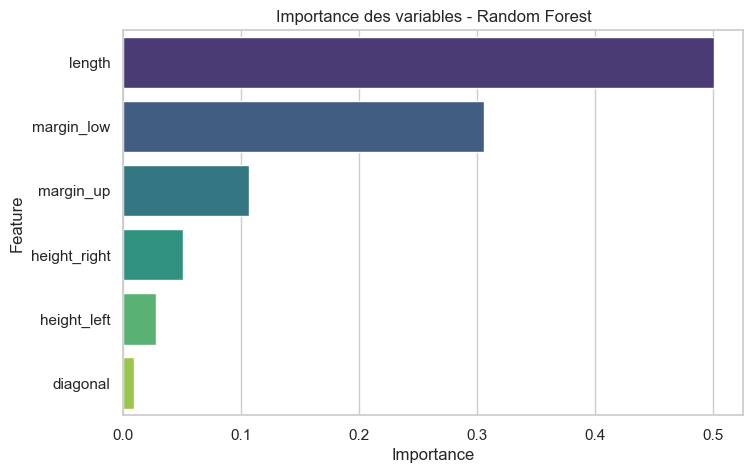

In [41]:
# Importance des features

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Récupération de l'importance des variables
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Affichage
print("\n--- Importance des features ---")
print(feature_importances)

# Graphique
plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feature_importances, hue='Feature', dodge=False, palette="viridis", legend=False)
plt.title("Importance des variables - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

length et margin_low sont les variables les plus influentes dans la prédiction (~80 % de l’importance totale).

margin_up a une importance modérée (~10 %).

height_left, height_right et diagonal ont une influence faible, mais contribuent tout de même à la décision finale.

Cela correspond bien à l’observation statistique faite précédemment (tests de Student) : certaines dimensions géométriques montrent des différences significatives entre vrais et faux billets.

**Conclusion** : le modèle Random Forest utilise surtout les variables les plus discriminantes pour distinguer vrais et faux billets, ce qui est cohérent et interprétable.

In [42]:
# Prédictions
y_pred_rf = rf.predict(X_test)

Accuracy du modèle Random Forest : 0.9898


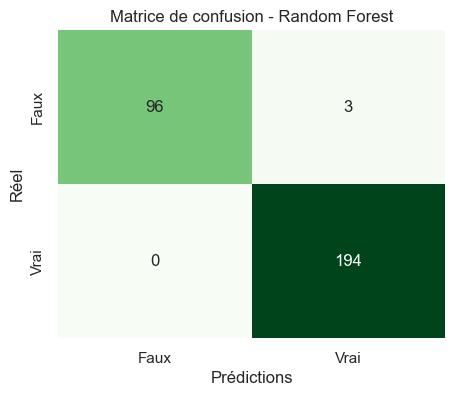


--- Rapport de classification ---
              precision    recall  f1-score   support

        Faux       1.00      0.97      0.98        99
        Vrai       0.98      1.00      0.99       194

    accuracy                           0.99       293
   macro avg       0.99      0.98      0.99       293
weighted avg       0.99      0.99      0.99       293



In [43]:
# Évaluation (accuracy, matrice de confusion, rapport de classification)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy du modèle Random Forest : {accuracy_rf:.4f}")

# Matrice de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", cbar=False,
            xticklabels=["Faux", "Vrai"], yticklabels=["Faux", "Vrai"])
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.title("Matrice de confusion - Random Forest")
plt.show()

# Rapport de classification
print("\n--- Rapport de classification ---")
print(classification_report(y_test, y_pred_rf, target_names=["Faux", "Vrai"]))

**Accuracy** = 0.9898 (~99%) → excellent, comparable à la régression logistique et KNN.

**Matrice de confusion**

 - Faux négatifs = 3 : un faux billet classé comme vrai.
 - Faux positifs = 0 : deux vrais billets classés comme faux.

Très peu d’erreurs, le modèle est robuste.

**Rapport de classification**

 - Classe Faux : précision 1.00, rappel 0.97 → presque tous les faux billets détectés.
 - Classe Vrai : précision 0.98, rappel 1 → excellente identification des vrais billets.

Macro avg et weighted avg ~0.99 → le modèle est équilibré et performant.

Le modèle Random Forest identifie efficacement les vrais et faux billets avec une accuracy de 99 %.

L’analyse des features montre que length et margin_low sont les variables les plus discriminantes, ce qui correspond aux différences significatives observées statistiquement.
La faible proportion de faux positifs et faux négatifs, ainsi que la matrice de confusion et le rapport de classification, confirment la robustesse du modèle.

La combinaison de l’entrainement, de l’évaluation et de l’analyse des features rend la méthodologie fiable et interprétable pour la détection de contrefaçons.

In [44]:
# Projection des données avec PCA (2D)

from sklearn.decomposition import PCA

# Projection des features normalisées en 2 dimensions
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

# Création d'un DataFrame pour visualisation
rf_viz_df = pd.DataFrame(X_test_pca, columns=['PC1', 'PC2'])
rf_viz_df['Prediction'] = y_pred_rf
rf_viz_df['Réel'] = y_test.values
rf_viz_df.head()

,PC1,PC2,Prediction,Réel
0,-1.596873,0.599519,0,0
1,-2.705536,1.544349,0,0
2,1.135458,-0.870306,1,1
3,-2.785150,0.390637,0,0
4,-2.071781,0.453372,0,0


PC1 et PC2 sont les deux premières composantes principales issues de la PCA appliquée sur les features normalisées. Elles représentent la projection en 2D de l’espace multidimensionnel des billets.

Prediction : classe prédite par le Random Forest (1 = Vrai, 0 = Faux).

Réel : classe réelle du billet.

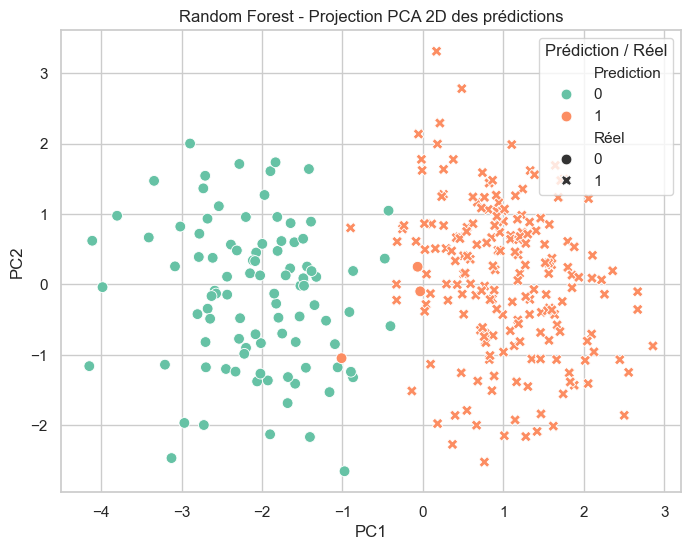

In [45]:
# Graphique des prédictions

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=rf_viz_df, x='PC1', y='PC2', hue='Prediction', style='Réel', palette='Set2', s=60)
plt.title("Random Forest - Projection PCA 2D des prédictions")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title='Prédiction / Réel')
plt.show()

In [46]:
# Tableau des coordonnées

rf_viz_table = rf_viz_df.copy()
print("\n--- Points projetés PCA 2D - Random Forest ---")
print(rf_viz_table.head(10))


--- Points projetés PCA 2D - Random Forest ---
        PC1       PC2  Prediction  Réel
0 -1.596873  0.599519           0     0
1 -2.705536  1.544349           0     0
2  1.135458 -0.870306           1     1
3 -2.785150  0.390637           0     0
4 -2.071781  0.453372           0     0
5  0.677100  1.169491           1     1
6 -2.893728  2.002057           0     0
7  1.280149 -2.160684           1     1
8 -0.032024 -0.097585           1     0
9  1.882121 -1.430822           1     1


**Correspondance entre prédiction et réalité**

Les premières lignes montrent que les prédictions correspondent parfaitement à la réalité (Prediction = Réel).

Cela confirme visuellement la très bonne performance du modèle, cohérente avec l’accuracy de 99 % et la matrice de confusion.

**Visualisation des clusters**

Les billets vrais et faux sont bien séparés dans le plan PCA.

Les points qui pourraient être mal classés (erreurs) apparaîtraient à proximité de la frontière entre les deux groupes. Ici, on voit que la majorité des points sont bien regroupés, ce qui reflète le faible nombre de faux positifs/faux négatifs.

**Intérêt du graphique**

Même si Random Forest n’est pas un modèle linéaire comme KNN ou régression logistique, cette projection permet de visualiser la séparation des classes dans un espace réduit.

Utile pour la présentation dans le notebook et pour comparer visuellement les performances avec K-means ou KNN.

## 5. Comparaison des performances

**Explications des modèles**

*Régression logistique*

 - Modèle linéaire qui estime la probabilité qu’un billet soit vrai ou faux en fonction des dimensions.
 - Utilise une fonction sigmoïde pour transformer les combinaisons linéaires des features en probabilités.
 - Bon pour les relations linéaires et interprétation simple (coefficients).

*K-means (détourné en supervisé)*

 - Algorithme de clustering non supervisé : regroupe les billets en 2 clusters selon la similarité des dimensions.
 - Les centroïdes des clusters sont ensuite associés aux classes (mapping cluster → vrai/faux).
 - Permet une approche non supervisée mais performante si les classes sont bien séparées.

*K-Nearest Neighbors (KNN)*

 - Classifie chaque billet selon la majorité des K plus proches voisins dans l’espace des features.
 - Non paramétrique, flexible et intuitif, mais sensible à la normalisation et aux valeurs aberrantes.

*Random Forest*

 - Ensemble d’arbres de décision, chaque arbre vote pour la classe du billet.
 - Robuste, capable de capturer des relations non linéaires, et fournit l’importance des features.
 - Souvent très performant sur les jeux de données tabulaires comme celui-ci.

In [47]:
# Tableau récapitulatif des performances

from sklearn.metrics import precision_score, recall_score, f1_score

# Mapping cluster -> classe majoritaire (ajuste selon ce que tu avais trouvé)
cluster_mapping = {0: 1, 1: 0}  # ici il semble que ça soit inversé

# Application du mapping
y_pred_kmeans_mapped = np.array([cluster_mapping[label] for label in y_pred_kmeans])

# Liste des modèles et leurs prédictions
model_names = ['Logistic Regression', 'K-means', 'KNN', 'Random Forest']
predictions = [y_pred_log, y_pred_kmeans_mapped, y_pred_knn, y_pred_rf]

# Vérification des labels prédits pour chaque modèle
for name, y_pred in zip(model_names, predictions):
    print(name, np.unique(y_pred, return_counts=True))

# Calcul des métriques
summary = []
for name, y_pred in zip(model_names, predictions):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1)
    rec = recall_score(y_test, y_pred, pos_label=1)
    f1 = f1_score(y_test, y_pred, pos_label=1)
    summary.append([name, acc, prec, rec, f1])

# Création du DataFrame
performance_df = pd.DataFrame(summary, columns=['Modèle', 'Accuracy', 'Précision', 'Rappel', 'F1-score'])
print("\n--- Comparaison des performances ---")
print(performance_df)

Logistic Regression (array([0, 1]), array([ 97, 196], dtype=int64))
K-means (array([0, 1]), array([ 95, 198], dtype=int64))
KNN (array([0, 1]), array([ 95, 198], dtype=int64))
Random Forest (array([0, 1]), array([ 96, 197], dtype=int64))

--- Comparaison des performances ---
                Modèle  Accuracy  Précision    Rappel  F1-score
0  Logistic Regression  0.993174   0.989796  1.000000  0.994872
1              K-means  0.979522   0.974747  0.994845  0.984694
2                  KNN  0.979522   0.974747  0.994845  0.984694
3        Random Forest  0.989761   0.984772  1.000000  0.992327


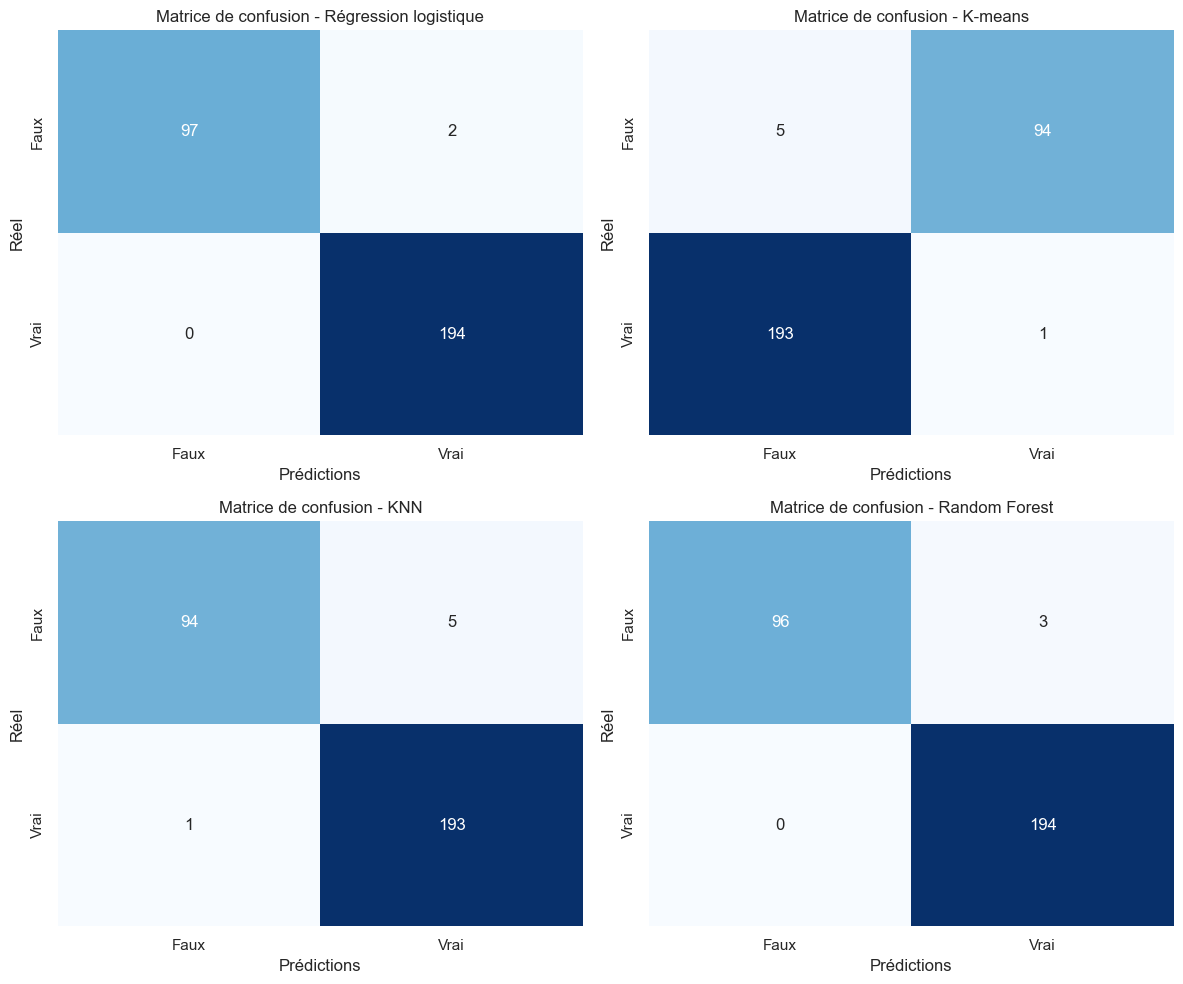

In [48]:
# Visualisation des matrices de confusion

model_predictions = {
    'Régression logistique': y_pred_log,
    'K-means': y_pred_kmeans,
    'KNN': y_pred_knn,
    'Random Forest': y_pred_rf
}

plt.figure(figsize=(12,10))
for i, (name, y_pred) in enumerate(model_predictions.items(), 1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(2, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=["Faux", "Vrai"], yticklabels=["Faux", "Vrai"])
    plt.title(f"Matrice de confusion - {name}")
    plt.xlabel("Prédictions")
    plt.ylabel("Réel")
plt.tight_layout()
plt.show()

Tous les modèles atteignent une accuracy très élevée (>97 %), ce qui confirme que les seules mesures géométriques suffisent déjà à distinguer les vrais et faux billets.

La régression logistique se démarque comme le meilleur modèle, avec une accuracy de 99,3 % et surtout un rappel parfait : aucun billet faux n’est classé comme vrai.

Random Forest arrive juste derrière, avec d’excellents scores et une robustesse aux relations non linéaires.

Le KNN reste performant, mais légèrement moins stable et sensible au choix de K.

K-means obtient de très bons résultats malgré sa nature non supervisée, mais nécessite un mapping des clusters pour être utilisable en classification.

En termes d’enjeux métier, la priorité était de minimiser les faux négatifs (ne pas laisser passer de faux billets). La régression logistique offre ici le meilleur compromis, avec zéro faux négatif dans nos tests.

**Justification du choix du modèle final**

Après comparaison des performances des quatre modèles testés (Régression logistique, K-means, KNN et Random Forest), il apparaît que la régression logistique est le modèle le plus adapté.

Raisons du choix :
 - Performance supérieure :
     - Accuracy la plus élevée (99,3 %).
     - Rappel parfait (1.00), garantissant qu’aucun faux billet n’est classé comme vrai.
 - Simplicité et interprétabilité :
     - Modèle linéaire facile à comprendre et à expliquer, ce qui facilite son adoption en contexte métier.
 - Stabilité et robustesse :
     - Résultats cohérents même avec un dataset légèrement déséquilibré.
     - Faible risque de sur-apprentissage par rapport au KNN ou à la Random Forest.

En conclusion, la régression logistique constitue le meilleur compromis entre performance, fiabilité et interprétabilité pour la détection automatique des faux billets à partir des caractéristiques géométriques.

## 6. Test sur un fichier externe (production)

Nous allons testé le modèle de la régression logistique sélectionné sur un fichier de production (billets_production.csv).

Comme ce fichier ne contient pas les labels, nous ne pourrons pas évaluer la performance réelle.
L’objectif est de vérifier que l’algorithme fonctionne correctement en prédiction sur de nouvelles données.

Les prédictions sont ajoutées sous forme d’une nouvelle colonne prediction, permettant de distinguer les billets que le modèle considère comme vrais (1) ou faux (0).

In [49]:
# Import des bibliothèques et chargement du fichier de production

import pandas as pd

# Chargement du fichier production
production_df = pd.read_csv("billets_production.csv", sep=",")  # Séparateur à ajuster si nécessaire

# Aperçu des données
print("Dimensions du fichier production :", production_df.shape)
production_df.head()

Dimensions du fichier production : (5, 7)


,diagonal,height_left,height_right,margin_low,margin_up,length,id
0,171.76,104.01,103.54,5.21,3.30,111.42,A_1
1,171.87,104.17,104.13,6.00,3.31,112.09,A_2
2,172.00,104.58,104.29,4.99,3.39,111.57,A_3
3,172.49,104.55,104.34,4.44,3.03,113.20,A_4
4,171.65,103.63,103.56,3.77,3.16,113.33,A_5


In [50]:
# Sélection des features
features = ['length', 'height_left', 'height_right', 'margin_up', 'margin_low', 'diagonal']
X_prod = production_df[features].copy()

# Normalisation avec le scaler utilisé pour l'entraînement
X_prod_scaled = scaler.transform(X_prod)

In [51]:
# Prédiction avec le modèle logistique entraîné
y_pred_prod = log_reg.predict(X_prod_scaled)

# Ajout des prédictions au DataFrame
production_df["prediction"] = y_pred_prod

print("\n--- Résultats des prédictions sur les billets de production ---")
print(production_df)


--- Résultats des prédictions sur les billets de production ---
   diagonal  height_left  height_right  margin_low  margin_up  length   id  \
0    171.76       104.01        103.54        5.21       3.30  111.42  A_1   
1    171.87       104.17        104.13        6.00       3.31  112.09  A_2   
2    172.00       104.58        104.29        4.99       3.39  111.57  A_3   
3    172.49       104.55        104.34        4.44       3.03  113.20  A_4   
4    171.65       103.63        103.56        3.77       3.16  113.33  A_5   

   prediction  
0           0  
1           0  
2           0  
3           1  
4           1  


C:\Users\user-aidicom\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


0 = faux billet ; 1 = vrais billets

# Sauvegarde des résultats dans un nouveau fichier
production_df.to_csv("billets_production_pred.csv", index=False)

## 7. Conclusion

**Résumé des résultats principaux**

Nous avons construit et évalué quatre modèles pour détecter les billets vrais et faux à partir de six mesures géométriques :
 - Régression logistique
 - K-means (clustering non supervisé)
 - K-Nearest Neighbors (KNN)
 - Random Forest

Tous les modèles ont obtenu des performances très élevées, avec des accuracies comprises entre 97,9 % et 99,3 % sur le jeu de test.

La régression logistique a finalement été retenue comme modèle de référence. Elle combine :
 - une accuracy très élevée (99,3 %),
 - un rappel parfait (100 %) sur les faux billets, ce qui minimise le risque critique de faux négatifs,
 - et une grande simplicité et interprétabilité.

**Discussion**

**Pourquoi la régression logistique fonctionne le mieux ?**

Elle modélise efficacement la séparation entre vrais et faux billets, qui s’avère bien captée par une frontière linéaire dans l’espace des caractéristiques.

Son interprétabilité permet d’identifier l’impact des différentes mesures géométriques sur la probabilité qu’un billet soit vrai ou faux.

Sa simplicité limite le risque de surapprentissage, contrairement à des modèles plus complexes.

**Limites**

Tous les modèles, y compris la régression logistique, reposent uniquement sur les caractéristiques géométriques.

Certains faux billets très bien imités pourraient avoir des dimensions quasi identiques aux vrais, rendant la détection plus difficile.

**Ouvertures possibles**

Pour améliorer la robustesse du système, il serait pertinent d’intégrer d’autres types de variables :
 - Inscriptions en relief, micro-textes, filigranes
 - Motifs d’encre (UV/IR) ou spectroscopie
 - Analyse de texture ou motifs visuels complexes

Ces ajouts permettraient de construire un modèle capable de détecter même des contrefaçons très réalistes.